# Analyse des ventes — Online Retail II

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from src.load_data import charger_ventes_en_ligne
from src.clean_transactions import nettoyer_transactions
from src.build_orders import construire_commandes
from src.calculate_kpis import (
    ajouter_variables_temporelles,
    calculer_kpi_commerciaux,
    calculer_ventes_mensuelles,
    calculer_ventes_quotidiennes,
)

donnees = charger_ventes_en_ligne()
donnees = nettoyer_transactions(donnees)
donnees = ajouter_variables_temporelles(donnees)
commandes = construire_commandes(donnees)

donnees.shape, commandes.shape

Matplotlib is building the font cache; this may take a moment.


((1067371, 23), (53628, 10))

## Indicateurs commerciaux globaux

In [2]:
import pandas as pd

kpi = calculer_kpi_commerciaux(donnees, commandes)
pd.Series(kpi)

chiffre_affaires_brut      2.097297e+07
valeur_annulations         1.685718e+06
chiffre_affaires_net       1.928725e+07
nombre_commandes           5.362800e+04
panier_moyen               3.596489e+02
articles_par_commande      1.978163e+02
prix_unitaire_moyen        4.649388e+00
clients_actifs             5.942000e+03
revenu_moyen_par_client    3.245919e+03
frequence_moyenne          9.025244e+00
dtype: float64

## Évolution mensuelle du chiffre d'affaires net

Décembre 2011 est exclu (mois incomplet, voir `docs/data_quality_report.md`).

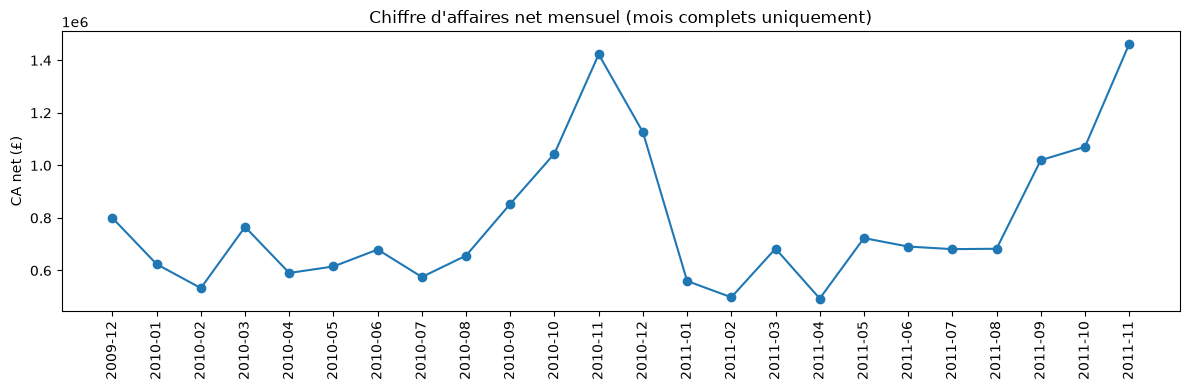

In [3]:
ventes_mensuelles = calculer_ventes_mensuelles(donnees)
ventes_mensuelles["periode"] = (
    ventes_mensuelles["year"].astype(str)
    + "-"
    + ventes_mensuelles["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 4))
plt.plot(ventes_mensuelles["periode"], ventes_mensuelles["net_revenue"], marker="o")
plt.xticks(rotation=90)
plt.title("Chiffre d'affaires net mensuel (mois complets uniquement)")
plt.ylabel("CA net (£)")
plt.tight_layout()
plt.show()

## Ventes par jour de la semaine

In [4]:
ordre_jours = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday",
]

ca_par_jour = (
    donnees.groupby("day_of_week")["line_revenue"].sum().reindex(ordre_jours)
)
ca_par_jour

day_of_week
Monday       3335216.106
Tuesday      3774873.772
Wednesday    3390238.013
Thursday     3995032.012
Friday       2955601.043
Saturday        9803.050
Sunday       1826486.572
Name: line_revenue, dtype: float64

## Ventes par heure

In [5]:
ca_par_heure = donnees.groupby("hour")["line_revenue"].sum().sort_index()
ca_par_heure

hour
6        -497.350
7       73941.220
8      524423.220
9     1549871.671
10    2456594.223
11    2351600.843
12    2728333.851
13    2391135.004
14    2250747.331
15    2168543.212
16    1534151.151
17     836170.682
18     265309.810
19     120805.710
20      36124.940
21         -4.950
Name: line_revenue, dtype: float64

## Top 10 pays par chiffre d'affaires net

In [6]:
top_pays = (
    donnees.groupby("country_clean")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_pays

country_clean
United Kingdom    1.638258e+07
Ireland           6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: line_revenue, dtype: float64

## Top 10 produits par chiffre d'affaires net

In [7]:
top_produits = (
    donnees.groupby(["stock_code", "description_clean"])["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_produits

stock_code  description_clean                  
22423       REGENCY CAKESTAND 3 TIER               327813.65
DOT         DOTCOM POSTAGE                         322647.47
85123A      WHITE HANGING HEART T-LIGHT HOLDER     253541.51
47566       PARTY BUNTING                          147948.50
85099B      JUMBO BAG RED RETROSPOT                146689.00
84879       ASSORTED COLOUR BIRD ORNAMENT          131413.85
22086       PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POST        POSTAGE                                112341.00
79321       CHILLI LIGHTS                           84854.16
84347       ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: line_revenue, dtype: float64

## Le chiffre d'affaires dépend-il de quelques clients ?

Nombre de clients nécessaires pour générer 50 % du chiffre d'affaires net.

In [8]:
revenu_par_client = (
    donnees.dropna(subset=["customer_id"])
    .groupby("customer_id")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
)

part_cumulee = revenu_par_client.cumsum() / revenu_par_client.sum()
nb_clients_pour_50pct = int((part_cumulee <= 0.5).sum() + 1)
nb_clients_total = revenu_par_client.shape[0]

print(
    f"{nb_clients_pour_50pct} clients sur {nb_clients_total} "
    f"({nb_clients_pour_50pct / nb_clients_total:.1%}) génèrent 50% du CA net"
)

270 clients sur 5942 (4.5%) génèrent 50% du CA net


## Le chiffre d'affaires dépend-il de quelques produits ?

In [9]:
revenu_par_produit = (
    donnees.groupby("stock_code")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
)

part_cumulee_produits = revenu_par_produit.cumsum() / revenu_par_produit.sum()
nb_produits_pour_50pct = int((part_cumulee_produits <= 0.5).sum() + 1)
nb_produits_total = revenu_par_produit.shape[0]

print(
    f"{nb_produits_pour_50pct} produits sur {nb_produits_total} "
    f"({nb_produits_pour_50pct / nb_produits_total:.1%}) génèrent 50% du CA net"
)

261 produits sur 5305 (4.9%) génèrent 50% du CA net


## Table quotidienne (base pour les analyses de tendance)

In [10]:
ventes_quotidiennes = calculer_ventes_quotidiennes(donnees, commandes)
ventes_quotidiennes.head()

,date,gross_revenue,cancelled_value,net_revenue,active_customers,units_sold,orders,average_order_value
0,2009-12-01,54513.50,1340.47,53173.03,117,24022,166,320.319458
1,2009-12-02,63352.51,588.92,62763.59,98,29942,133,471.906692
2,2009-12-03,74037.91,5944.86,68093.05,116,44896,150,453.953667
3,2009-12-04,40732.92,386.52,40346.40,82,21001,107,377.069159
4,2009-12-05,9803.05,-0.00,9803.05,26,5033,32,306.345312


## Export

In [ ]:
commandes.to_csv(Path("../data/processed/orders.csv"), index=False)
ventes_quotidiennes.to_csv(Path("../data/processed/daily_sales.csv"), index=False)
print("Fichiers exportés dans data/processed/")